# Multi-Agent Multi-Armed Bandits: 
## application to EVs smart charging with grid constraints

In [3]:
from matplotlib import pyplot as plt
from simulation.simulation import *
from utils.plot_analysis import *
from strategies import *
from utils.strategy_comparison import *
from tqdm.notebook import tqdm
import pickle
import os

# Define the path to the results
# base_path = "test_results_120ev_80nf_1200area_1000ep_limit/"
Strategy.register("FTPL-IRS-EXP", MABFTPL)
Strategy.register("FTPL-IRS-F2", MABFTPL)
Strategy.register("Inde-TS", MABTS)
Strategy.register("FTPL-IRS", MABFTPL)
Strategy.register("GREEDY", Baseline)
Strategy.register("EV_DRL", DRL)
# add drl


base_path = "./results_ECML2026/"
strategies_and_samples_dict = find_strategies_and_samples(base_path, verbose=True)

Strategies and samples found:
  - .ipynb_checkpoints: 0
  - CA: 1
  - Test: 2
  - default: 1
  - images: 2
  - tables: 1


## Load all results

results_ECML2026/Test\EVs_5/
Strategies and samples found:
  - EV_DRL: 4


Strategies (N=5): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 91.69it/s]
D:\Autonomy\Rennus\Simulator\ecml2026\src\utils\strategy_comparison.py:1098: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=legend_fontsize,framealpha = 0.7,ncol=1)


Saved: results_ECML2026/images/Test/agent0_cumloss_N5_ep0_1459_mean_std.pdf


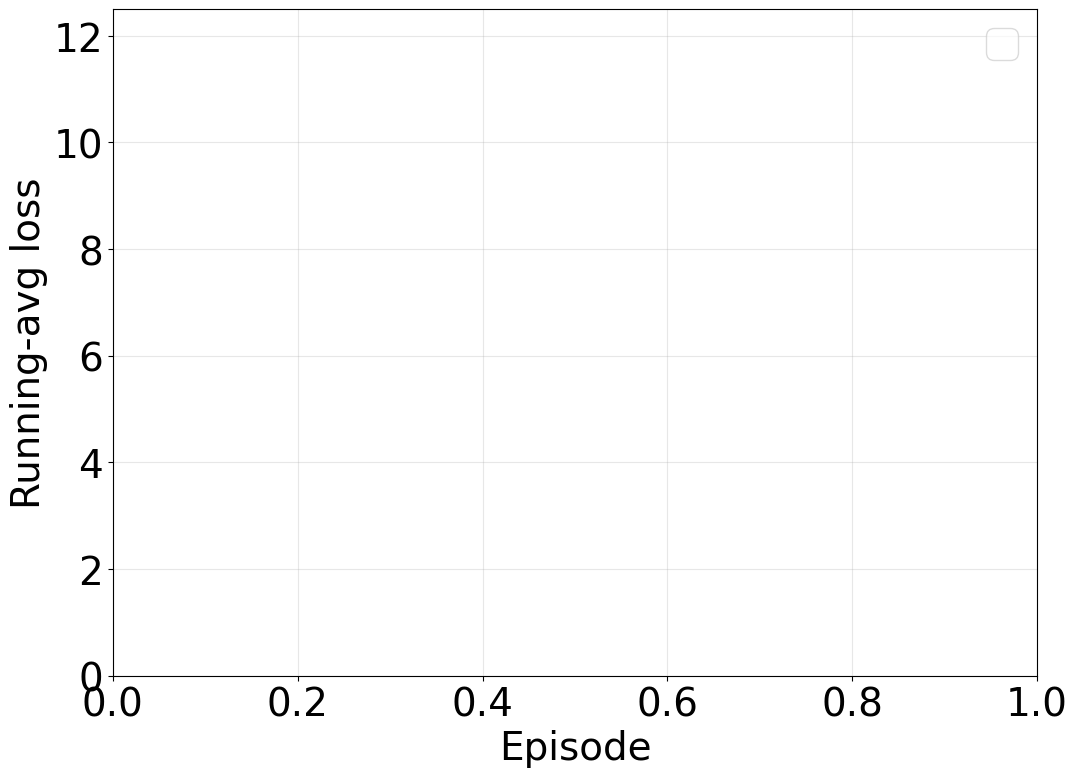

results_ECML2026/Test\EVs_5/
Strategies and samples found:
  - EV_DRL: 4


Strategies (N=5): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 70.12it/s]

Saved: results_ECML2026/images/cumloss-default/agent0_cumloss_N5_ep0_1459_mean_std.pdf



D:\Autonomy\Rennus\Simulator\ecml2026\src\utils\strategy_comparison.py:1098: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=legend_fontsize,framealpha = 0.7,ncol=1)


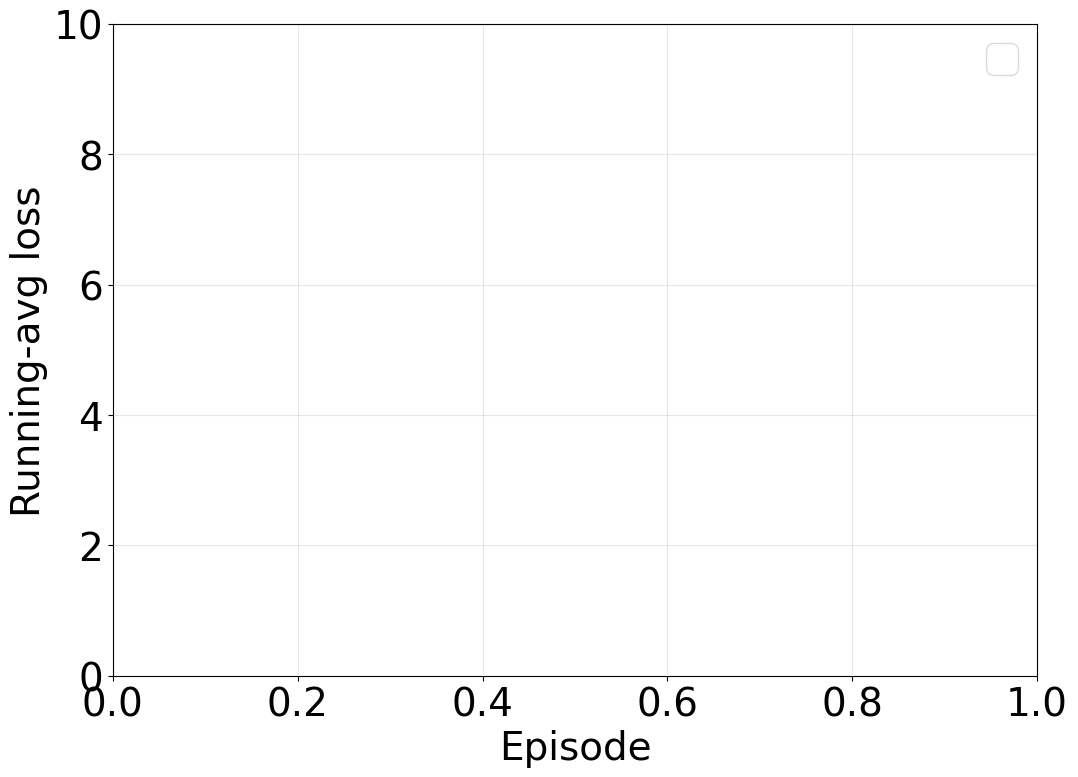

In [4]:
cmp = StrategyComparison(
    path="results_ECML2026/Test",  # or whatever root contains EVs_{N}/
    n_agents=5,
    verbose=True,
)


fig, ax = cmp.plot_agent_cumulative_loss_from_disk(
    ev_id=0,                 # which agent to plot
    episode_start=0,
    episode_end=1459,
    cumulative_mode="mean",  # running average of cumulative sum
    band="std",              # "std" or "minmax"
    save_path="results_ECML2026/images/Test/",
    figsize=(11,8),
     legend_fontsize=28,
    tick_fontsize=28,
    axis_label_fontsize=28,
    ylim = 12.5
)

cmp = StrategyComparison(
    path="results_ECML2026/Test",  # or whatever root contains EVs_{N}/
    n_agents=5,
    verbose=True,
)


fig, ax = cmp.plot_agent_cumulative_loss_from_disk(
    ev_id=0,                 # which agent to plot
    episode_start=0,
    episode_end=1459,
    cumulative_mode="mean",  # running average of cumulative sum
    band="std",              # "std" or "minmax"
    save_path="results_ECML2026/images/cumloss-default/",
    figsize=(11,8),
    legend_fontsize=28,
    tick_fontsize=28,
    axis_label_fontsize=28,
    ylim = 10.0
)

Skip

In [7]:
# num_ev_agents = [30,60,120,240,480,960]
num_ev_agents = [5]
computation_table = [num_ev_agents, []]

base_path = "./results_ECML2026/"

for n in num_ev_agents:
    sc = StrategyComparison(path=base_path+"CA/", n_agents=n, verbose=False)
    table = sc.compute_time_table_from_disk()
    computation_table[1].append(table)

with open(base_path+"tables/computation_table.pkl", "wb") as f:
    pickle.dump(computation_table, f)


Strategies (N=5): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:39<00:00,  7.94s/it]


FileNotFoundError: [Errno 2] No such file or directory: './results_ECML2026/tables/computation_table.pkl'

In [ ]:
base_path = "./results_ECML2026/"

sc = StrategyComparison(path=base_path+"CA/", n_agents=5, verbose=False)  # n_agents here doesn't matter for plotting pickle
full_df = sc.plot_mean_computation_time_vs_N_from_pickle(
    pkl_path=base_path+"tables/computation_table.pkl",
    loglog=False,
    save_path=base_path+"images"+"/mean_time_vs_N_minmax.pdf",
    figsize=(9,11),
    linewidth=2.5
    , legend_fontsize=28,
    tick_fontsize=32,
    axis_label_fontsize=32,
)

### Strategy Results Organization

For these functions, place all the strategy results you want to compare in a new **FULL** folder.

Each strategy variant must use a **different folder name** for each variants, for example:

FTPL-IRS-F2 for the default loss mode training, FTPL-IRS-F2-CA for the congestion_aware loss mode training

results_ECML2026/CA\EVs_5/
Strategies and samples found:
  - FTPL-IRS-EXP: 10
  - FTPL-IRS-F2: 10
  - GREEDY: 10
  - Inde-TS: 10
  - MILP_Price_Forecast: 10


Strategies (N=5): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:41<00:00,  8.20s/it]


Saved: results_ECML2026_bis/images\congestion_frequency_N5_days0_1460_roll20_stdband.pdf


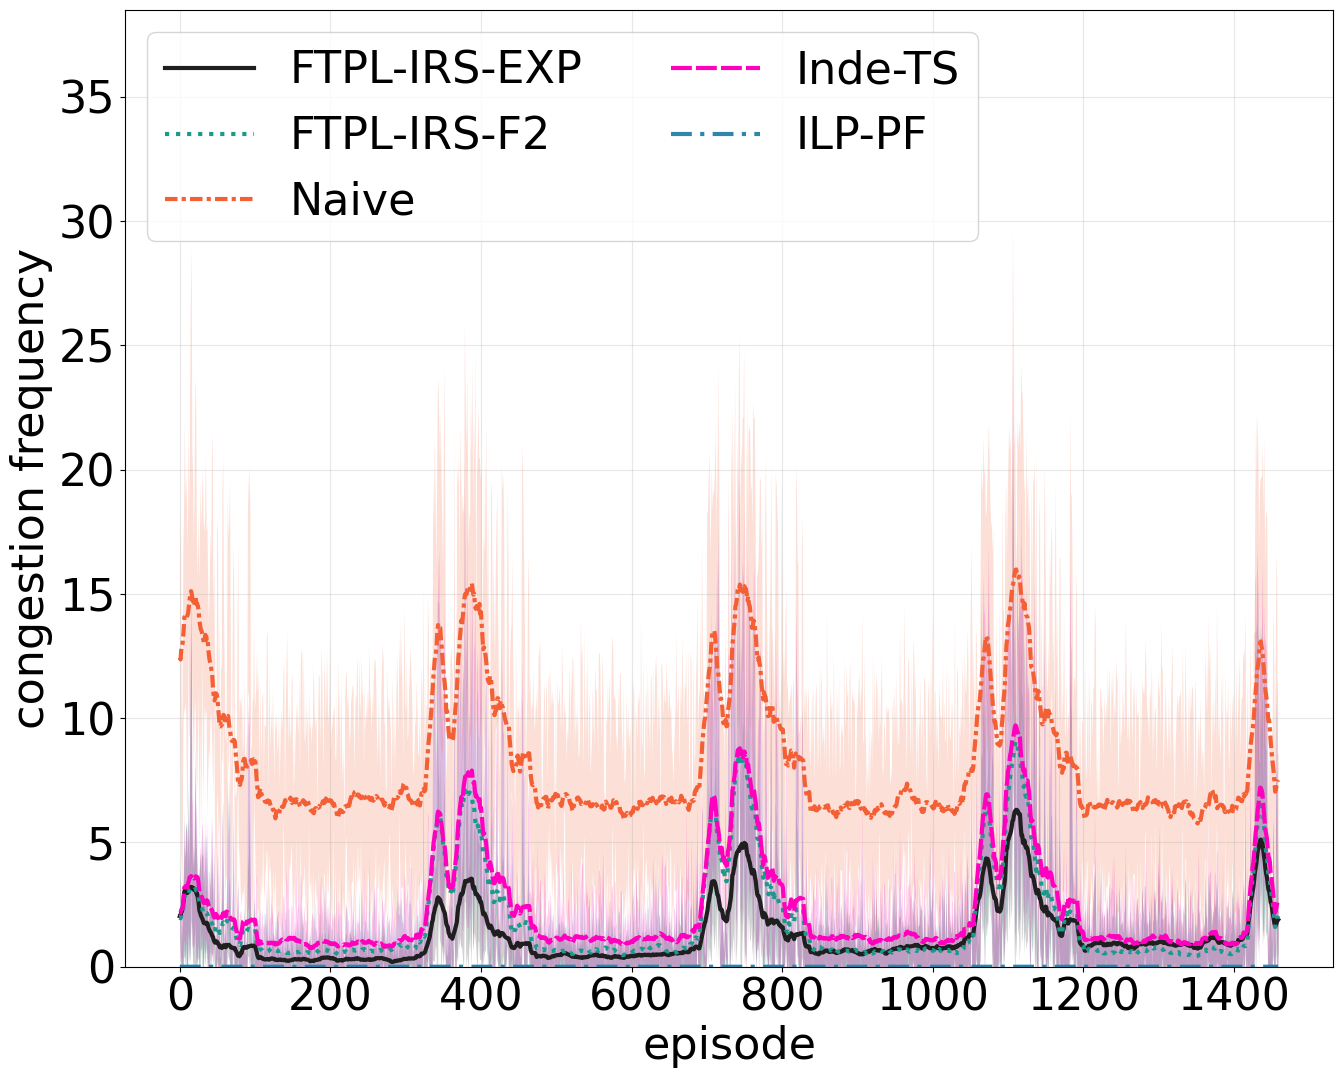

(<Figure size 1400x1100 with 1 Axes>,
 <Axes: xlabel='episode', ylabel='congestion frequency'>)

In [8]:
cmp = StrategyComparison(
    path="results_ECML2026/CA",  # or whatever root contains EVs_{N}/ # FULL to CA
    n_agents=5,
    verbose=True,
)

cmp.plot_congestion_frequency_from_disk(window_size=20,legend_fontsize=32,
    tick_fontsize=32,
    axis_label_fontsize=32,
    figsize=(14,11))

In [11]:
cmp = StrategyComparison(
    path="results_ECML2026/default",
    n_agents=5,
    verbose=True,
)

import os, gc
import numpy as np



df = cmp.compute_old_metrics_scientific_table_from_disk(
    naive_strategy="GREEDY",
    optimal_strategy="MILP_Price_Forecast",
    price_day_start=0,
    price_day_end=None,
    cong_day_start=0,
    cong_day_end=1459,
    save_dir="results_ECML2026/tables",
    filename="disk_scientific_5metrics.pkl",
)

display(df)


results_ECML2026/default\EVs_5/
Strategies and samples found:
  - FTPL-IRS-EXP: 10
  - FTPL-IRS-F2: 10
  - GREEDY: 10
  - Inde-TS: 10


Strategies (N=5): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:35<00:00,  8.95s/it]


Saved: results_ECML2026/tables\disk_scientific_5metrics.pkl


,Strategy,N_agents,Price_final_norm (mean),Price_final_norm (std),Price_n_seeds,Total_congestive_instants (mean),Total_congestive_instants (std),Congestion_n_seeds,Avg_disconnections_per_agent (mean),Avg_disconnections_per_agent (std),Disconnections_n_seeds,Regret_price_vs_Naive (mean),Regret_price_vs_Naive (std),Regret_price_vs_Naive (n),Regret_price_vs_ILP-PF (mean),Regret_price_vs_ILP-PF (std),Regret_price_vs_ILP-PF (n)
0,FTPL-IRS-EXP,5,12.551360,0.074362,10,2393.2,89.849009,10,596.28,24.230963,10,0.446892,0.085971,10,NaN,NaN,0
1,FTPL-IRS-F2,5,9.518815,0.075877,10,9237.9,236.894468,10,2947.60,77.174550,10,-2.585653,0.103125,10,NaN,NaN,0
2,Naive,5,12.104467,0.051570,10,12093.7,97.832112,10,4013.64,40.071580,10,0.000000,0.000000,10,NaN,NaN,0
3,Inde-TS,5,9.033774,0.032695,10,9590.7,130.935141,10,2979.12,51.614399,10,-3.070693,0.069154,10,NaN,NaN,0
